# Cement Strength Detection

## Importing headers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.mixture import GaussianMixture

import tensorflow as tf

## Extracting and exploring dataset

In [3]:
df=pd.read_csv('concrete.csv')
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


### Univariate Analysis

We check the features and the data types of the features.

In [4]:
keys=df.keys()
keys

Index(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg',
       'fineagg', 'age', 'strength'],
      dtype='object')

In [ ]:
df.dtypes

cement          float64
slag            float64
ash             float64
water           float64
superplastic    float64
coarseagg       float64
fineagg         float64
age               int64
strength        float64
dtype: object

We see some of the common statistics of the dataset such as central values, standard deviations, quartiles, range.

In [ ]:
df.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


Now we'll check the distributions of all the columns.

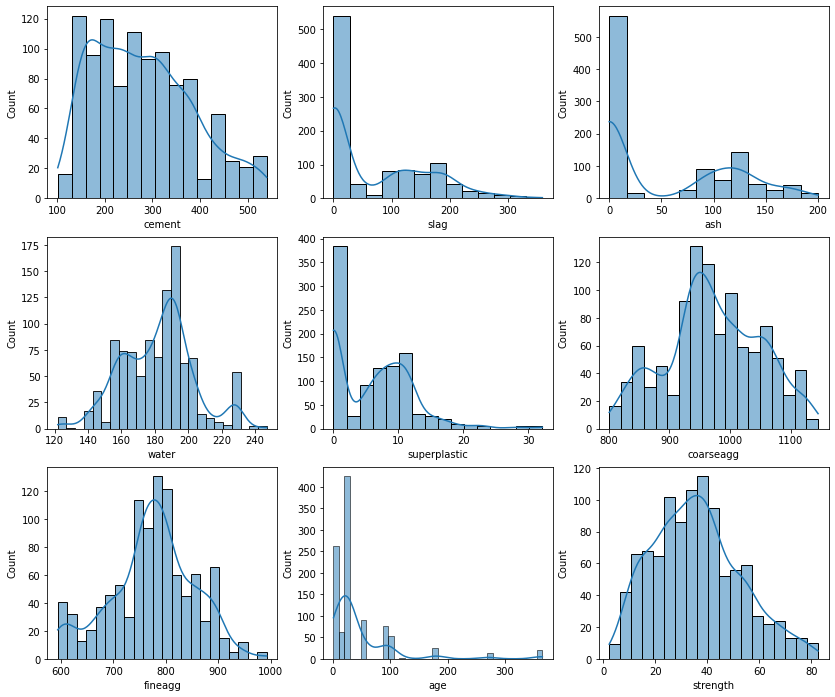

In [ ]:
plt.figure(figsize=(14,12))

for i in range(len(keys)):
  plt.subplot(3,3,i+1)
  sns.histplot(x=keys[i],data=df,kde=True)
  # plt.title(keys[i])


### Multivariate Analysis

We check the pairwise plot of every columns (for same column it shows the histogram).

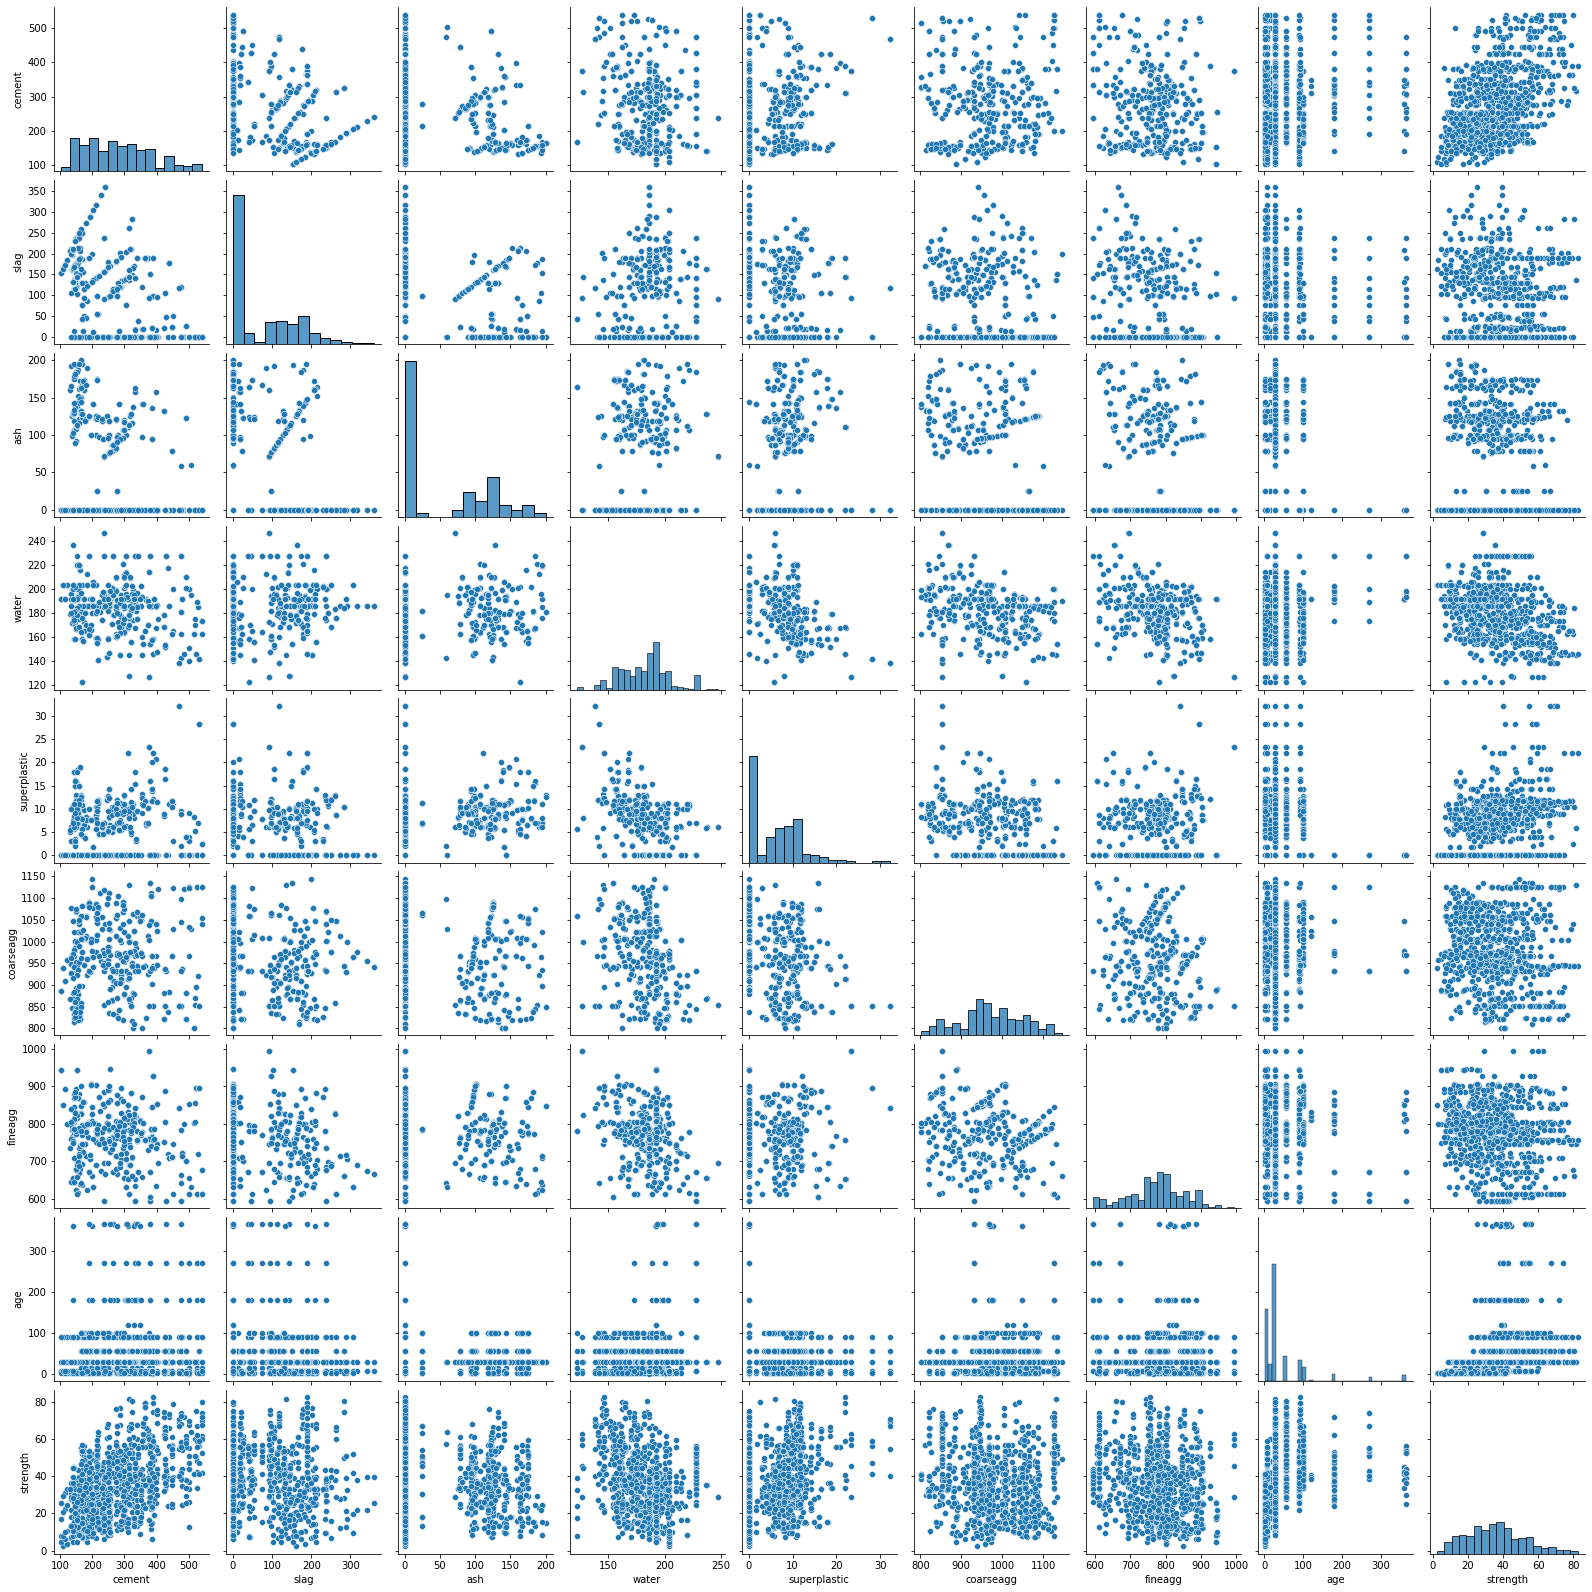

In [ ]:
sns.pairplot(df)

Now we check the correlation among each columns.

In [ ]:
df.corr()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
superplastic,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
coarseagg,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
fineagg,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


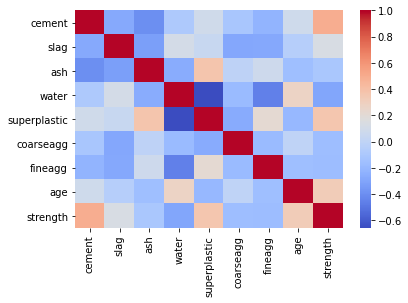

In [ ]:
sns.heatmap(df.corr(),cmap='coolwarm')

We can see there isn't any strong correlation between any two variables.

### Outliers and missing values

Checking for any missing values:

In [ ]:
for key in keys:
  print(pd.isna(df[key]).any())

False
False
False
False
False
False
False
False
False


We can see none of the columns have Null values.

**Outliers**

We use box plot to check presence of outliers.

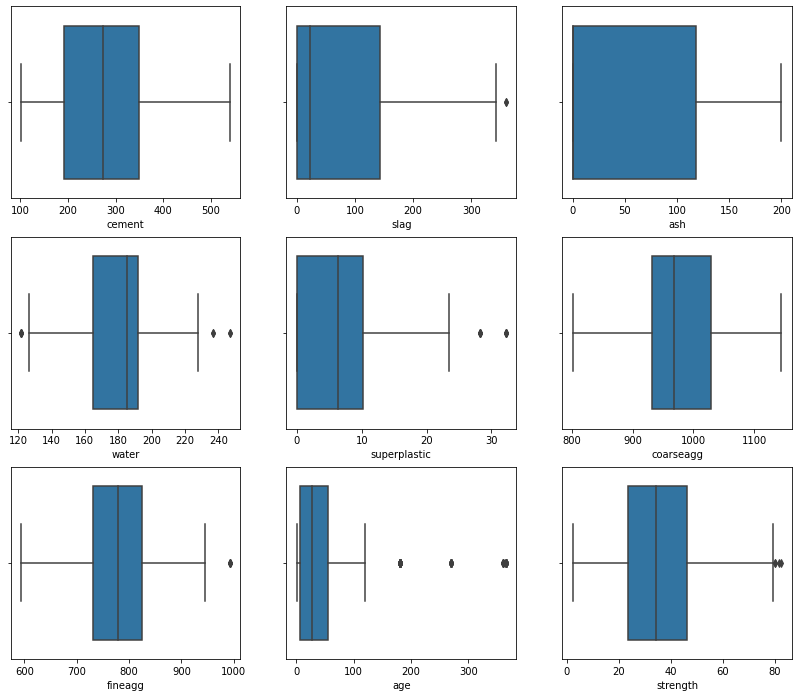

In [ ]:
plt.figure(figsize=(14,12))

for i in range(len(keys)):
  plt.subplot(3,3,i+1)
  sns.boxplot(x=keys[i],data=df)

We can see that 5 columns contain outliers. 

Let us see the interquartile range.

In [27]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

cement          157.625
slag            142.950
ash             118.300
water            27.100
superplastic     10.200
coarseagg        97.400
fineagg          93.050
age              49.000
strength         22.425
dtype: float64


Now, using this IQR, we remove the outliers from the dataset.

In [28]:
df = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]

## Model

We extract our input and output variables into X and Y.

In [5]:
X=df.iloc[:,:-1].values
Y=df.iloc[:,-1].values

We split the data into training and testing set with a ratio 4:1.

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

### Simple Linear Regression

We use simple linear regression model.

We train the model using our training set data.

Then we evaluate the model using coefficient of determination R^2, which lies between 0 and 1.

In [ ]:
model=LinearRegression()
model.fit(X_train, Y_train)

print("Training score : ", model.score(X_train, Y_train))
print("Testing score : ", model.score(X_test, Y_test))

Training score :  0.7723958578292599
Testing score :  0.757236656222505


We see the results are around 0.75 to 0.77, which means around 25% to 23% of the variability in the outcome data cannot be explained by the model.

Let us plot the output.

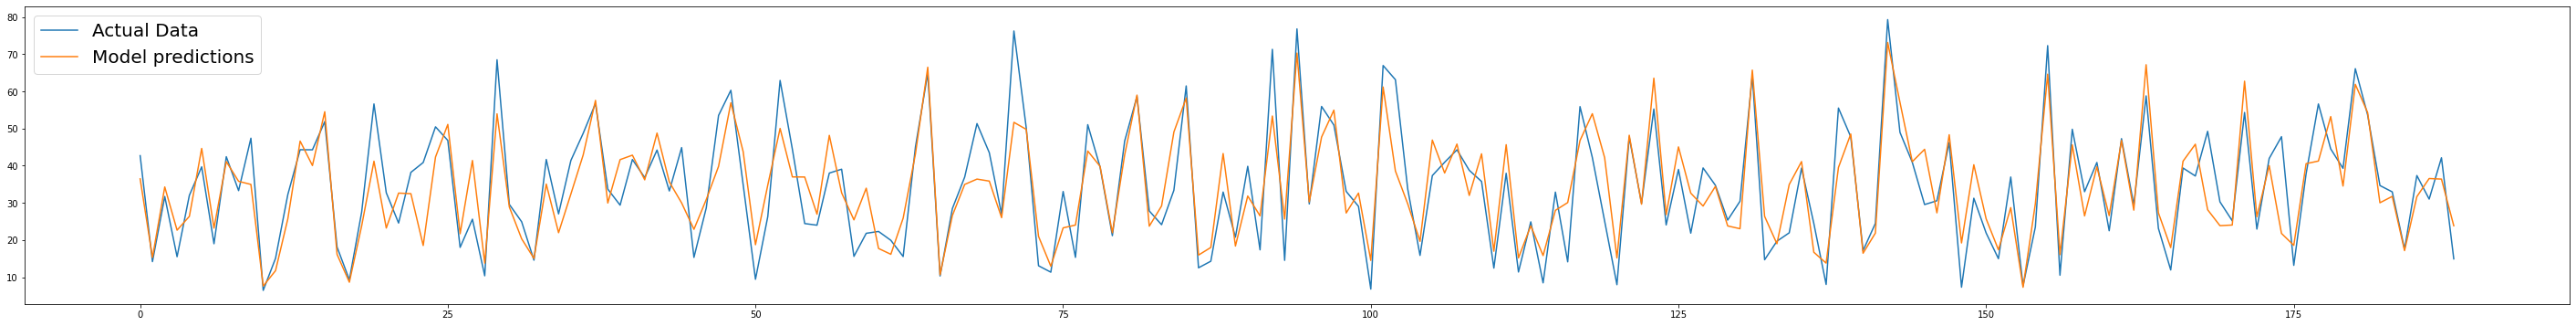

In [ ]:
plt.figure(figsize=(50,6))
plt.plot(Y_test)
plt.plot(model.predict(X_test))
plt.legend(['Actual Data','Model predictions'],loc='upper left',fontsize=20)

It's not a very bad fit, but there might be scope for improvement.


Let us check the importance of features

Feature: 0, Score: 0.10316
Feature: 1, Score: 0.07465
Feature: 2, Score: 0.05224
Feature: 3, Score: -0.26324
Feature: 4, Score: 0.12913
Feature: 5, Score: -0.01064
Feature: 6, Score: -0.01015
Feature: 7, Score: 0.31390


<BarContainer object of 8 artists>

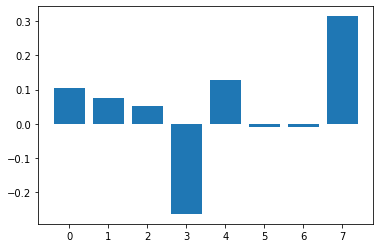

In [ ]:
importance = model.coef_

for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
plt.bar([x for x in range(len(importance))], importance)

We can see that features 5 and 6 are not very important. So let us drop those features and see if there's any major change in score.

In [ ]:
X=df.iloc[:,[0,1,2,3,4,7]].values
Y=df.iloc[:,-1].values

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

model=LinearRegression()
model.fit(X_train, Y_train)

print("Training score : ", model.score(X_train, Y_train))
print("Testing score : ", model.score(X_test, Y_test))

Training score :  0.7719401708712088
Testing score :  0.7569328250153171


We can see the results are almost the same, so let us proceed with these features.

### Polynomial Regression

We try polynomial linear regression.

We convert the input to polynomial features of degree 2.

In [ ]:
poly = PolynomialFeatures(2)

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

X_train=poly.fit_transform(X_train)
X_test=poly.fit_transform(X_test)

On this polynomial input, we perform linear regression.

In [ ]:
model=LinearRegression()
model.fit(X_train, Y_train)

print("Training score : ", model.score(X_train, Y_train))
print("Testing score : ", model.score(X_test, Y_test))

Training score :  0.8022145978036257
Testing score :  0.789763936790008


We have better results.

Let us plot the output.

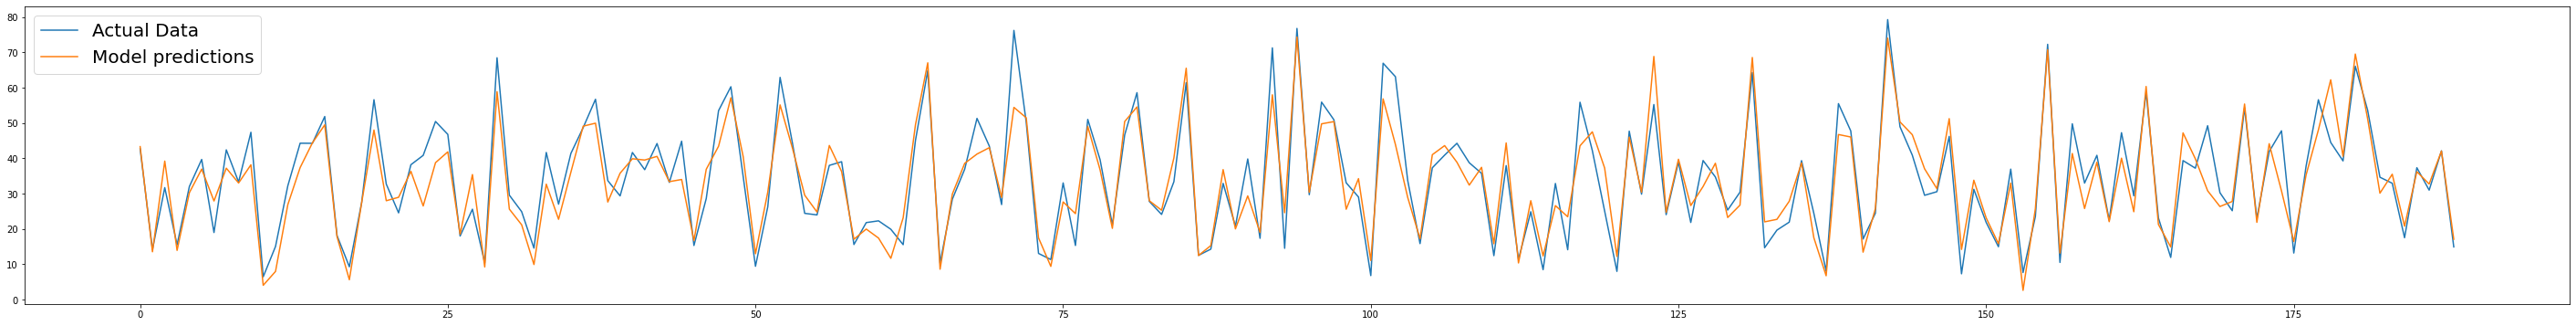

In [ ]:
plt.figure(figsize=(50,6))
plt.plot(Y_test)
plt.plot(model.predict(X_test))
plt.legend(['Actual Data','Model predictions'],loc='upper left',fontsize=20)

The output has improved.

Now let us perform k-fold cross validation to perform validation.


In [ ]:
# Fold
cv=12

scores = sklearn.model_selection.cross_val_score(estimator=model, X=X_train, y=Y_train, cv=cv, scoring='r2')
print(scores)

print("\n Mean score: ",scores.mean())


[0.80398671 0.86704556 0.89933471 0.82742788 0.81448675 0.84348824
 0.85196655 0.81475097 0.85780074 0.88241959 0.84028746 0.88454532]

 Mean score:  0.8489617082911405


We have a mean r^2 score of around 0.84, which indicates a good fit.

### Gaussian Mixture Model

Looking at the age column, we can see there are certain age groups. These can be thought of as clusters. 

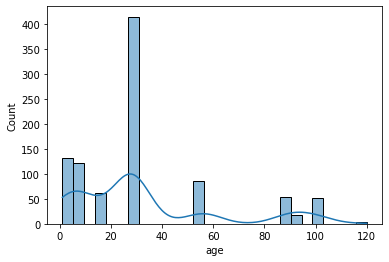

In [29]:
sns.histplot(df.iloc[:,-2],kde=True)

This looks like a combination of gaussian distributions. 
Let us try to fit Gaussian Mixture Model on this using 4 clusters.

In [101]:
data=pd.DataFrame(df.iloc[:,-2].values.reshape(-1,1),columns=['age'])
data.head()

,age
0,28
1,14
2,28
3,28
4,28


In [102]:
# We take 4 clusters
n=4
gmm = GaussianMixture(n_components=4)
gmm.fit(data)

GaussianMixture(covariance_type='full', init_params='kmeans', max_iter=100,
                means_init=None, n_components=4, n_init=1, precisions_init=None,
                random_state=None, reg_covar=1e-06, tol=0.001, verbose=0,
                verbose_interval=10, warm_start=False, weights_init=None)

In [103]:
labels=gmm.predict(data)
data['Clusters']=labels
data.head()

,age,Clusters
0,28,1
1,14,2
2,28,1
3,28,1
4,28,1


In [104]:
color=['plum','greenyellow','tomato','orange']

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


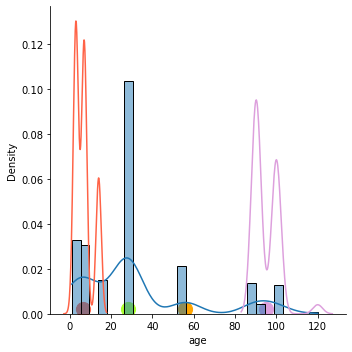

In [114]:
sns.displot(data['age'],kde=True,stat='density')

for i in range(n):
    dt=data[data['Clusters']==i]
    sns.kdeplot(dt['age'],c=color[i])
    plt.scatter([gmm.means_[i]],0.002,c=color[i],s=200,marker='o')

These are the clusters.

The scattered colored markers represent the means of the distributions.

Let us plot the data points with respect to the dependent output, i.e strength.

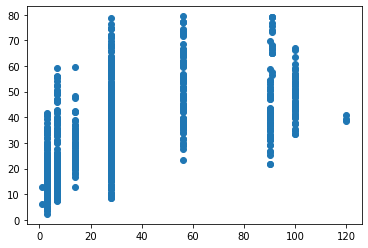

In [118]:
data=df.iloc[:,[-2,-1]]
plt.scatter(data.iloc[:,0],data.iloc[:,1])

Gaussian Mixture Model is a soft clustering method which would work for our case.

In [119]:
# We take 4 clusters
n=4
gmm = GaussianMixture(n_components=4)
gmm.fit(data)

GaussianMixture(covariance_type='full', init_params='kmeans', max_iter=100,
                means_init=None, n_components=4, n_init=1, precisions_init=None,
                random_state=None, reg_covar=1e-06, tol=0.001, verbose=0,
                verbose_interval=10, warm_start=False, weights_init=None)

In [120]:
labels = gmm.predict(data)

data['Clusters']=labels

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [124]:
from matplotlib.patches import Ellipse

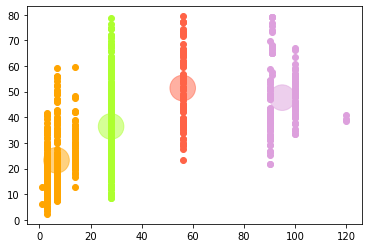

In [140]:
plt.figure()
ax = plt.gca()

for k in range(n):
  data_cluster=data[data['Clusters']==k]
  ax.scatter(data_cluster['age'],data_cluster['strength'],c=color[k])
  ax.add_patch(Ellipse((gmm.means_[k,0],gmm.means_[k,1]),10,10,color=color[k],alpha=0.5))

We can form clusters of age in this way as we can see in the above colored scatter plot.

The transparent circles represent the means of the clusters.

### Artificial Neural Network

Here we implement a moderately deep neural network.

In [141]:
X=df.iloc[:,[0,1,2,3,4,7]].values
Y=df.iloc[:,-1].values

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [142]:
# Scaling the features

scaler=sklearn.preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [143]:
# Creating model

model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(128,input_dim=X.shape[1],activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(1,activation='linear'))
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 128)               896       
_________________________________________________________________
dense_1 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_2 (Dense)              (None, 64)                4160      
_________________________________________________________________
dense_3 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 33        
Total params: 15,425
Trainable params: 15,425
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Compiling and training

opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt,loss='mse',metrics='mse')
history=model.fit(X_train,Y_train,epochs=2000, validation_data=(X_test, Y_test))

Epoch 1/2000
24/24 [==============================] - 1s 9ms/step - loss: 1475.6928 - mse: 1475.6928 - val_loss: 1428.5309 - val_mse: 1428.5309
Epoch 2/2000
24/24 [==============================] - 0s 4ms/step - loss: 1499.5565 - mse: 1499.5565 - val_loss: 1415.5222 - val_mse: 1415.5222
Epoch 3/2000
24/24 [==============================] - 0s 3ms/step - loss: 1423.0315 - mse: 1423.0315 - val_loss: 1398.8767 - val_mse: 1398.8767
Epoch 4/2000
24/24 [==============================] - 0s 3ms/step - loss: 1447.9713 - mse: 1447.9713 - val_loss: 1374.2262 - val_mse: 1374.2262
Epoch 5/2000
24/24 [==============================] - 0s 3ms/step - loss: 1356.8791 - mse: 1356.8791 - val_loss: 1337.4207 - val_mse: 1337.4207
Epoch 6/2000
24/24 [==============================] - 0s 3ms/step - loss: 1417.0920 - mse: 1417.0920 - val_loss: 1283.4110 - val_mse: 1283.4110
Epoch 7/2000
24/24 [==============================] - 0s 3ms/step - loss: 1405.8438 - mse: 1405.8438 - val_loss: 1207.4095 - val_mse: 12

Let us vizualise the loss.

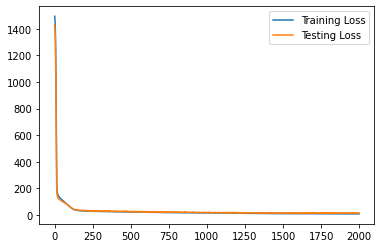

In [ ]:
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.legend(['Training Loss','Testing Loss'])

We can see there is no case of overfitting happening. 

Now let us check the R^2 scores.

In [ ]:
print("{:.2f}".format(sklearn.metrics.r2_score(Y_train, model.predict(X_train))))

0.97


In [ ]:
print("{:.2f}".format(sklearn.metrics.r2_score(Y_test, model.predict(X_test))))

0.95


We can see the R^2 values are 0.97 and 0.95 for training and testing data respectively, thus implying a good fit.